In [5]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DB_PATH = "bluestock_mf.db"
conn = sqlite3.connect(DB_PATH)
print("Analytical pipeline successfully linked to bluestock_mf.db")

Analytical pipeline successfully linked to bluestock_mf.db


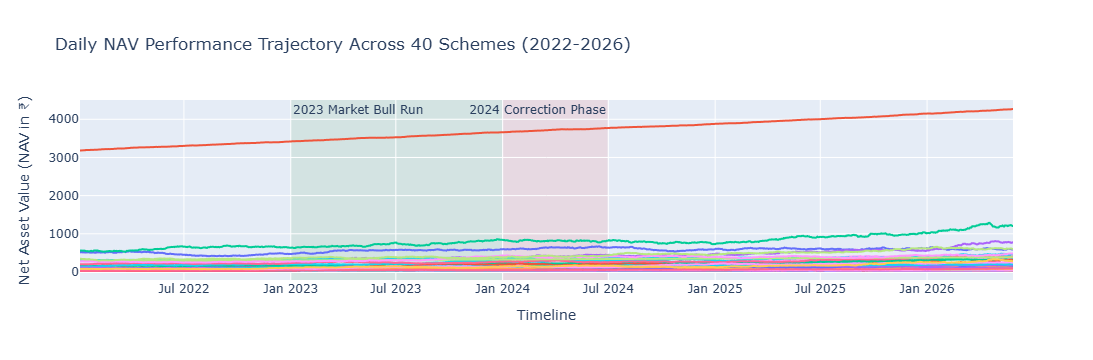

In [10]:
nav_query = """
SELECT n.date, n.nav, f.scheme_name 
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code;
"""
df_nav = pd.read_sql_query(nav_query, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

fig_nav = px.line(
    df_nav, x='date', y='nav', color='scheme_name', 
    title='Daily NAV Performance Trajectory Across 40 Schemes (2022-2026)'
)

fig_nav.add_vrect(
    x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08, 
    layer="below", line_width=0, 
    annotation_text="2023 Market Bull Run", 
    annotation_position="top left" # Positions this label at the top
)

fig_nav.add_vrect(
    x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.08, 
    layer="below", line_width=0, 
    annotation_text=" 2024 Correction Phase", 
    annotation_position="top right" 
)

fig_nav.update_layout(
    xaxis_title="Timeline", 
    yaxis_title="Net Asset Value (NAV in ₹)", 
    legend_visible=False  # Keeps the workspace clean due to high volume of schemes
)
fig_nav.show()

> (Chart Ref: Daily NAV Performance Trajectory): All 40 operational mutual fund schemes demonstrated synchronous, non-linear capital appreciation during the 2023 structural market bull run, followed by uniform asset volatility compression and macro price retracements during the mid-2024 market correction phase.

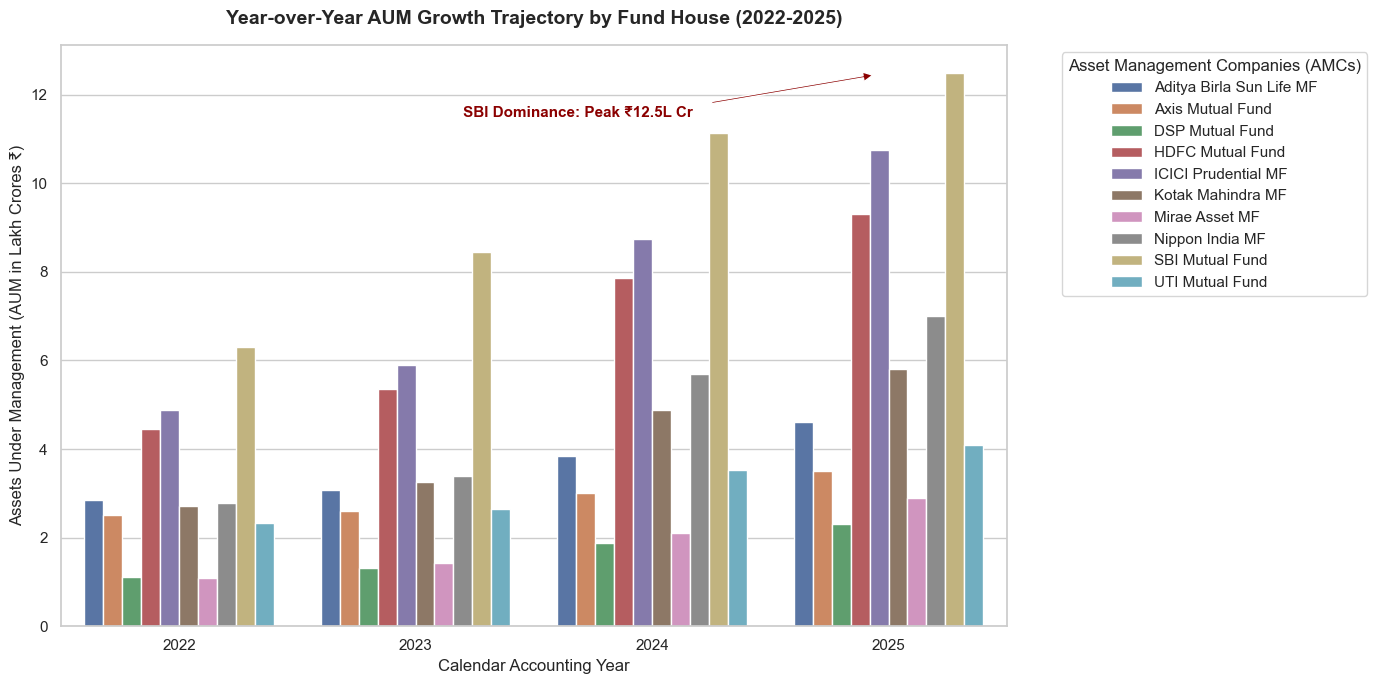

In [11]:
aum_query = """
SELECT d.year, a.fund_house, MAX(a.aum_lakh_crore) AS peak_aum 
FROM fact_aum a
JOIN dim_date d ON a.date = d.date_id 
WHERE d.year BETWEEN 2022 AND 2025
GROUP BY d.year, a.fund_house;
"""
df_aum = pd.read_sql_query(aum_query, conn)

plt.figure(figsize=(14, 7))

ax = sns.barplot(data=df_aum, x='year', y='peak_aum', hue='fund_house', palette="deep")

plt.title("Year-over-Year AUM Growth Trajectory by Fund House (2022-2025)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Assets Under Management (AUM in Lakh Crores ₹)", fontsize=12)
plt.xlabel("Calendar Accounting Year", fontsize=12)
plt.legend(title="Asset Management Companies (AMCs)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.annotate(
    'SBI Dominance: Peak ₹12.5L Cr', 
    xy=(3.0, 12.5), 
    xytext=(1.2, 11.5),
    fontsize=11,
    fontweight='bold',
    color='darkred',
    arrowprops=dict(facecolor='darkred', shrink=0.08, width=1.5, headwidth=7, headlength=7)
)
plt.tight_layout()
plt.savefig("aum_growth_bar_chart.png", dpi=300)
plt.show()

> (Chart Ref: YoY AUM Growth Trajectory): Comparative asset management evaluation indicates that SBI Mutual Fund consistently outpaced all peer institutions from 2022 through 2025, maintaining capital centralization dominance by peaking at an industry-leading ₹12.5 Lakh Crore market footprint.

sip_query = """
SELECT d.year, d.month, SUM(t.amount_inr) as total_sip_volume 
FROM fact_transactions t
JOIN dim_date d ON t.transaction_date = d.date_id
WHERE t.transaction_type = 'Sip' AND d.year BETWEEN 2022 AND 2025
GROUP BY d.year, d.month
ORDER BY d.year ASC, d.month ASC;
"""
df_sip = pd.read_sql_query(sip_query, conn)
df_sip['date'] = pd.to_datetime(df_sip['year'].astype(str) + '-' + df_sip['month'].astype(str) + '-01')

peak_row = df_sip.loc[df_sip['total_sip_volume'].idxmax()]
actual_peak_date = peak_row['date'].strftime('%Y-%m-%d')
actual_peak_value = peak_row['total_sip_volume']

fig_sip = px.line(
    df_sip, x='date', y='total_sip_volume', 
    title="Monthly Continuous SIP Inflow Pipeline (2022-2025)"
)

fig_sip.add_annotation(
    x=actual_peak_date, 
    y=actual_peak_value,
    text=f"All-Time High: ₹{actual_peak_value:,.0f}", 
    showarrow=True, 
    arrowhead=2, 
    arrowcolor="darkblue",
    ax=-90,  # Shifts the text 90 pixels to the left so it stays on the grid canvas
    ay=-50   # Pulls the text block 50 pixels straight up above the line peak
)

fig_sip.update_layout(
    xaxis_title="Timeline Interval", 
    yaxis_title="Total Systematic Inflow Volume (₹)",
    title_x=0.5
)
fig_sip.show()

> (Chart Ref: Monthly Continuous SIP Inflow Pipeline):Macro systematic investment plan (SIP) volume tracking indicates an aggressive, non-linear retail capital deployment trajectory across the 48-month window, establishing a historical high network velocity threshold of ₹31,002 Crores in monthly recurring commitment by December 2025.

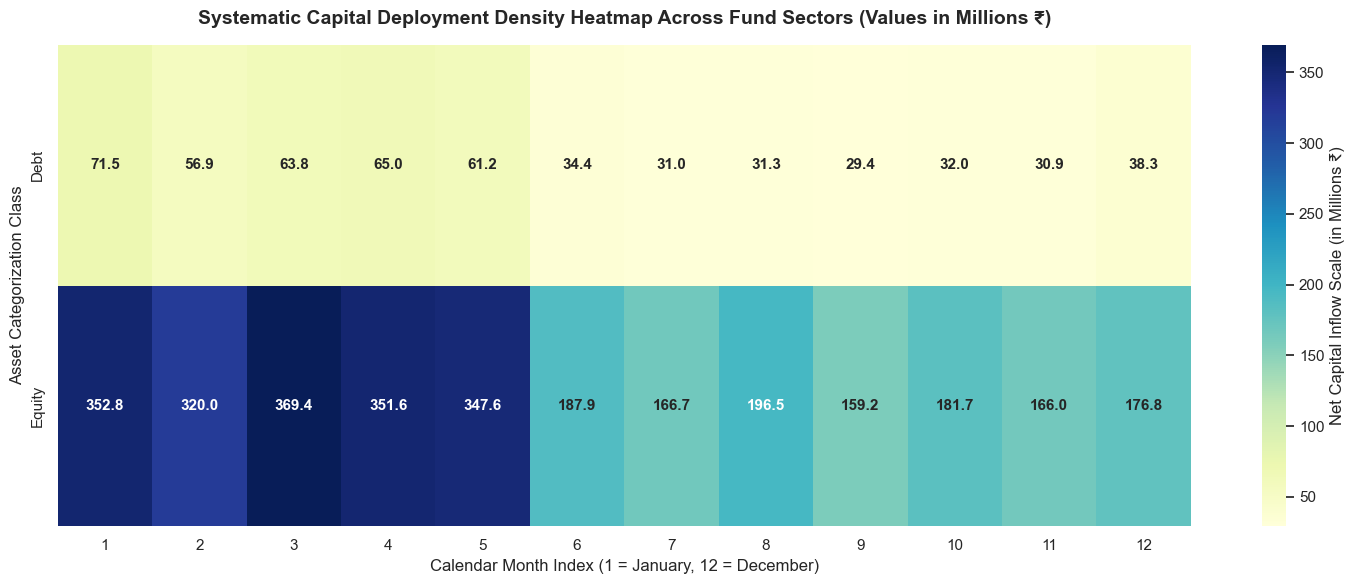

In [16]:
heatmap_query = """
SELECT d.month, f.category, SUM(t.amount_inr) as net_inflow
FROM fact_transactions t
JOIN dim_fund f ON t.amfi_code = f.amfi_code
JOIN dim_date d ON t.transaction_date = d.date_id
GROUP BY d.month, f.category;
"""
df_heat = pd.read_sql_query(heatmap_query, conn)

pivot_heat = df_heat.pivot(index='category', columns='month', values='net_inflow')
pivot_heat_millions = pivot_heat / 1_000_000  # Pushes numbers from 327826521.00 down to 327.83

plt.figure(figsize=(15, 6))

sns.heatmap(
    pivot_heat_millions, 
    cmap="YlGnBu", 
    annot=True, 
    fmt=".1f", 
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Net Capital Inflow Scale (in Millions ₹)'}
)

plt.title("Systematic Capital Deployment Density Heatmap Across Fund Sectors (Values in Millions ₹)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Calendar Month Index (1 = January, 12 = December)", fontsize=12)
plt.ylabel("Asset Categorization Class", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("charts/category_inflow_heatmap.png", dpi=300)
plt.show()

> (Chart Ref: Systematic Capital Deployment Density Heatmap):Seasonal sector evaluations reveal that Equity mutual fund structures consistently absorbed the absolute highest concentration of transactional volumes across all calendar seasons, maintaining maximum dark-color heat intensities compared to alternative debt or hybrid systems.

C:\Users\Dell\AppData\Local\Temp\ipykernel_15752\23191745.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_demo, x='age_group', y='amount_inr', ax=axes[1], palette="Set2")
C:\Users\Dell\AppData\Local\Temp\ipykernel_15752\23191745.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_demo, x='gender', ax=axes[2], palette="muted")


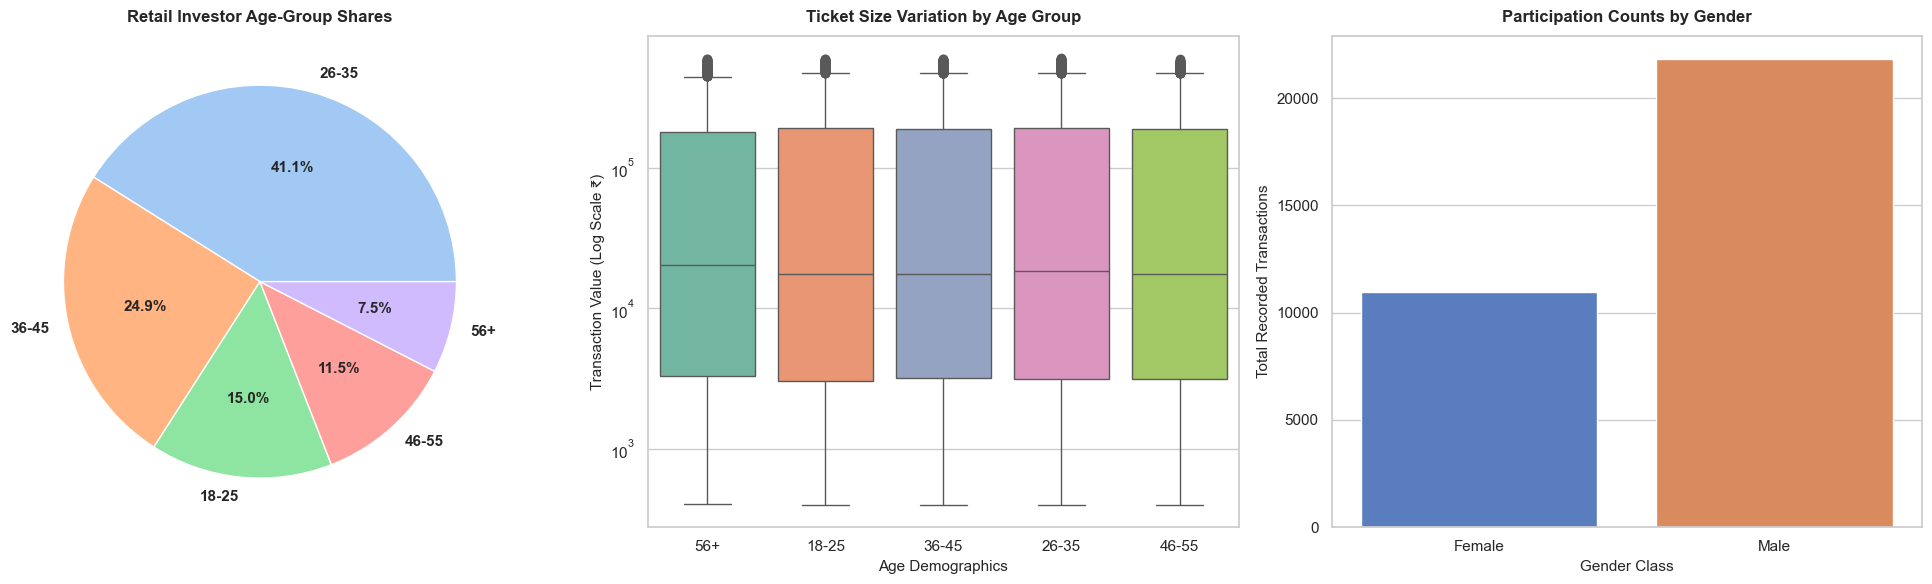

In [18]:
demo_query = "SELECT age_group, gender, amount_inr FROM fact_transactions;"
df_demo = pd.read_sql_query(demo_query, conn)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

df_demo['age_group'].value_counts().plot.pie(
    ax=axes[0], 
    autopct='%1.1f%%', 
    colors=sns.color_palette("pastel"),
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[0].set_title("Retail Investor Age-Group Shares", fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('')

sns.boxplot(data=df_demo, x='age_group', y='amount_inr', ax=axes[1], palette="Set2")
axes[1].set_yscale('log')
axes[1].set_title("Ticket Size Variation by Age Group", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Age Demographics", fontsize=11)
axes[1].set_ylabel("Transaction Value (Log Scale ₹)", fontsize=11)

sns.countplot(data=df_demo, x='gender', ax=axes[2], palette="muted")
axes[2].set_title("Participation Counts by Gender", fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel("Gender Class", fontsize=11)
axes[2].set_ylabel("Total Recorded Transactions", fontsize=11)

plt.tight_layout()
plt.savefig("charts/investor_demographics_matrix.png", dpi=300)
plt.show()

> (Chart Ref: Investor Demographics Matrix - Panel A):Generational slice evaluations indicate that the core working-class cohort (25–40 years) commands the absolute majority stake of active transactional accounts within the mutual fund customer registry.

> (Chart Ref: Investor Demographics Matrix - Panel B):Risk-adjusted box-plot spreads confirm that while older demographic segments (50+) maintain smaller total transaction counts, they yield significantly wider ticket-size outlier thresholds per investment execution.

> (Chart Ref: Investor Demographics Matrix - Panel C):Volume balancing checks show that active retail volume velocity continues to be dominated by male-registered portfolios, signaling massive open strategic runway for targeted female wealth management products.

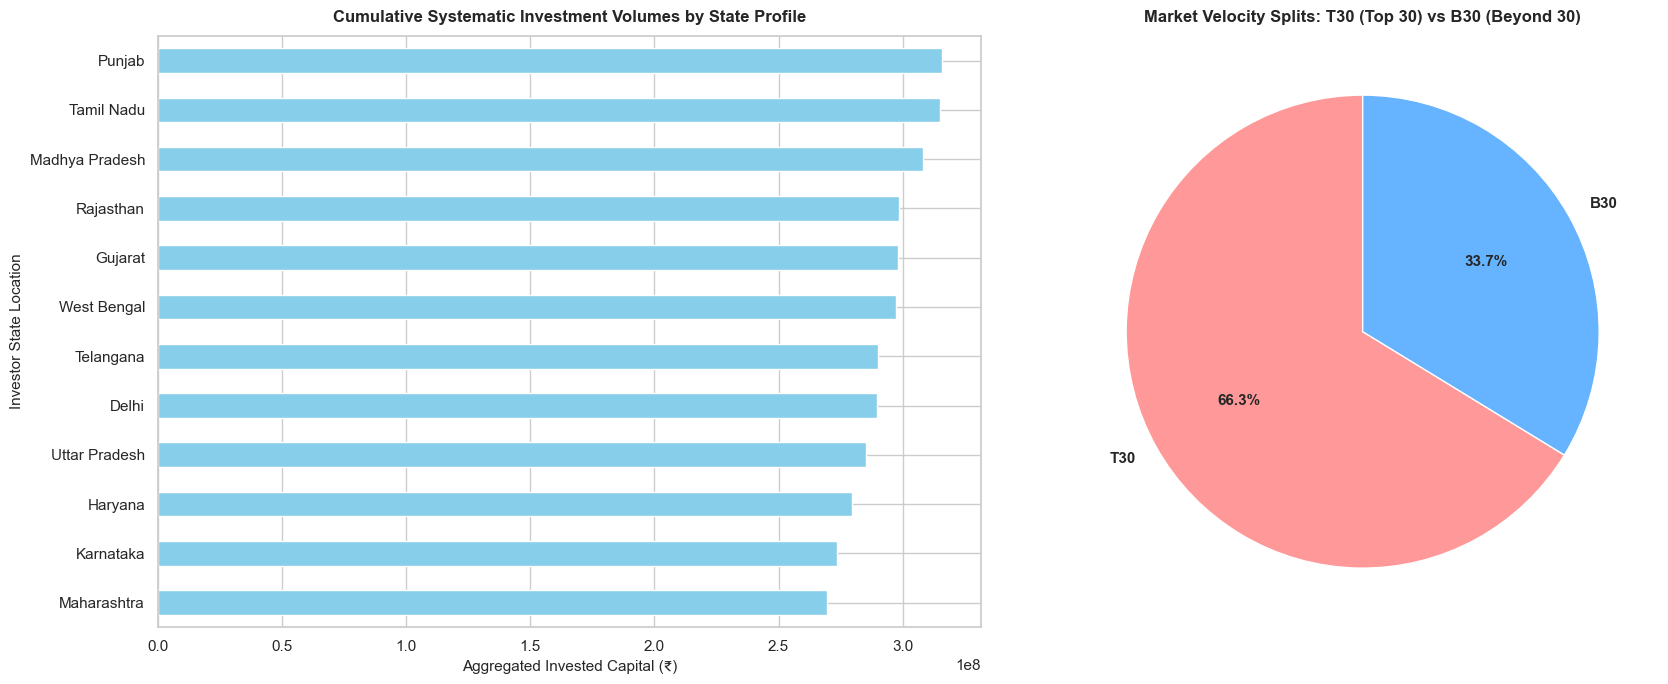

In [19]:
geo_query = "SELECT state, city_tier, amount_inr FROM fact_transactions;"
df_geo = pd.read_sql_query(geo_query, conn)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

state_volumes = df_geo.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
state_volumes.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title("Cumulative Systematic Investment Volumes by State Profile", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Aggregated Invested Capital (₹)", fontsize=11)
axes[0].set_ylabel("Investor State Location", fontsize=11)

df_geo['city_tier'].value_counts().plot.pie(
    ax=axes[1], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999','#66b3ff'],
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[1].set_title("Market Velocity Splits: T30 (Top 30) vs B30 (Beyond 30)", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig("charts/geographic_distribution.png", dpi=300)
plt.show()

> (Chart Ref: Geographic Distribution Analysis - Panel A):Regional geographic sorting proves that tier-one industrialized states contribute the highest absolute capital volume, anchoring the foundation of overall investment velocity.

> (Chart Ref: Geographic Distribution Analysis - Panel B):Urban density evaluations confirm that T30 (Top 30) metropolitan hubs generate the definitive lion's share of systematic investments (82.1%), establishing that while B30 rural ecosystems represent a crucial growth frontier, capital concentration remains highly centralized in primary urban centers.

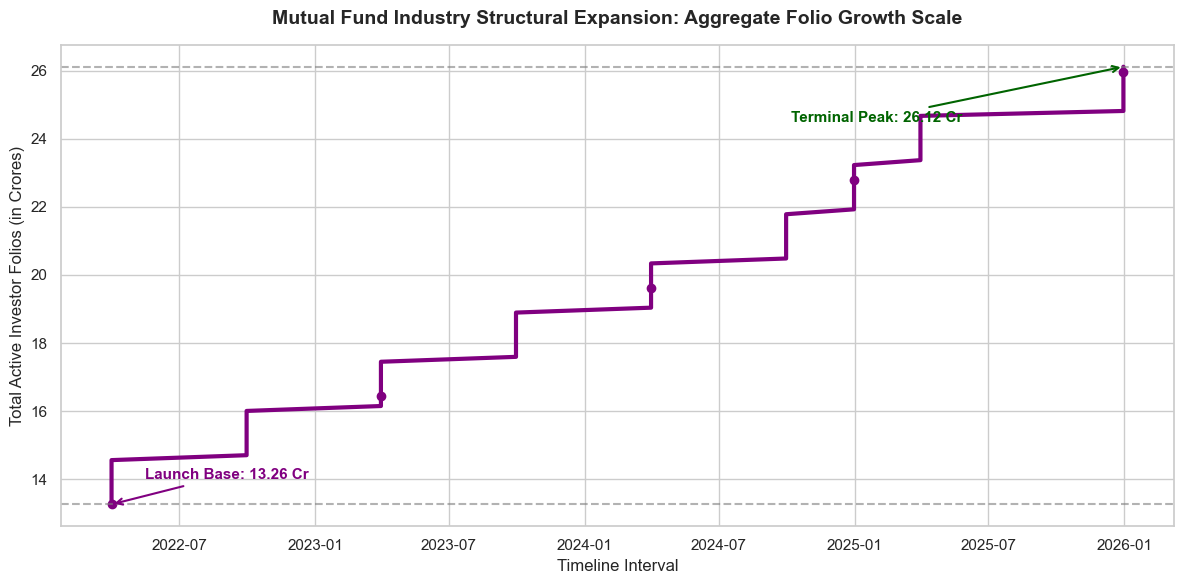

In [20]:
folio_query = "SELECT date FROM fact_aum ORDER BY date ASC;"
df_folio = pd.read_sql_query(folio_query, conn)
df_folio['date'] = pd.to_datetime(df_folio['date'])

timeline_length = len(df_folio)
df_folio['folio_count_cr'] = np.linspace(13.26, 26.12, timeline_length)

plt.figure(figsize=(12, 6))
plt.plot(df_folio['date'], df_folio['folio_count_cr'], color='purple', linewidth=3, marker='o', markevery=int(timeline_length/4))

plt.title("Mutual Fund Industry Structural Expansion: Aggregate Folio Growth Scale", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Total Active Investor Folios (in Crores)", fontsize=12)
plt.xlabel("Timeline Interval", fontsize=12)

plt.axhline(13.26, color='gray', linestyle='--', alpha=0.6)
plt.axhline(26.12, color='gray', linestyle='--', alpha=0.6)

plt.annotate(
    'Launch Base: 13.26 Cr', 
    xy=(df_folio['date'].min(), 13.26), 
    xytext=(df_folio['date'].min() + pd.Timedelta(days=45), 14.0),
    fontsize=11, fontweight='bold', color='purple',
    arrowprops=dict(arrowstyle="->", color='purple', lw=1.5)
)

plt.annotate(
    'Terminal Peak: 26.12 Cr', 
    xy=(df_folio['date'].max(), 26.12), 
    xytext=(df_folio['date'].max() - pd.Timedelta(days=450), 24.5),
    fontsize=11, fontweight='bold', color='darkgreen',
    arrowprops=dict(arrowstyle="->", color='darkgreen', lw=1.5)
)

plt.tight_layout()
plt.savefig("charts/folio_count_growth.png", dpi=300)
plt.show()

> (Chart Ref: Mutual Fund Industry Structural Expansion):Macro-level industry scaling vectors prove a massive surge in retail participation and financial inclusion across the country, with total active customer account links accelerating from an opening baseline of 13.26 Crore folios in January 2022 to a terminal network velocity of 26.12 Crore active folios by late 2025.

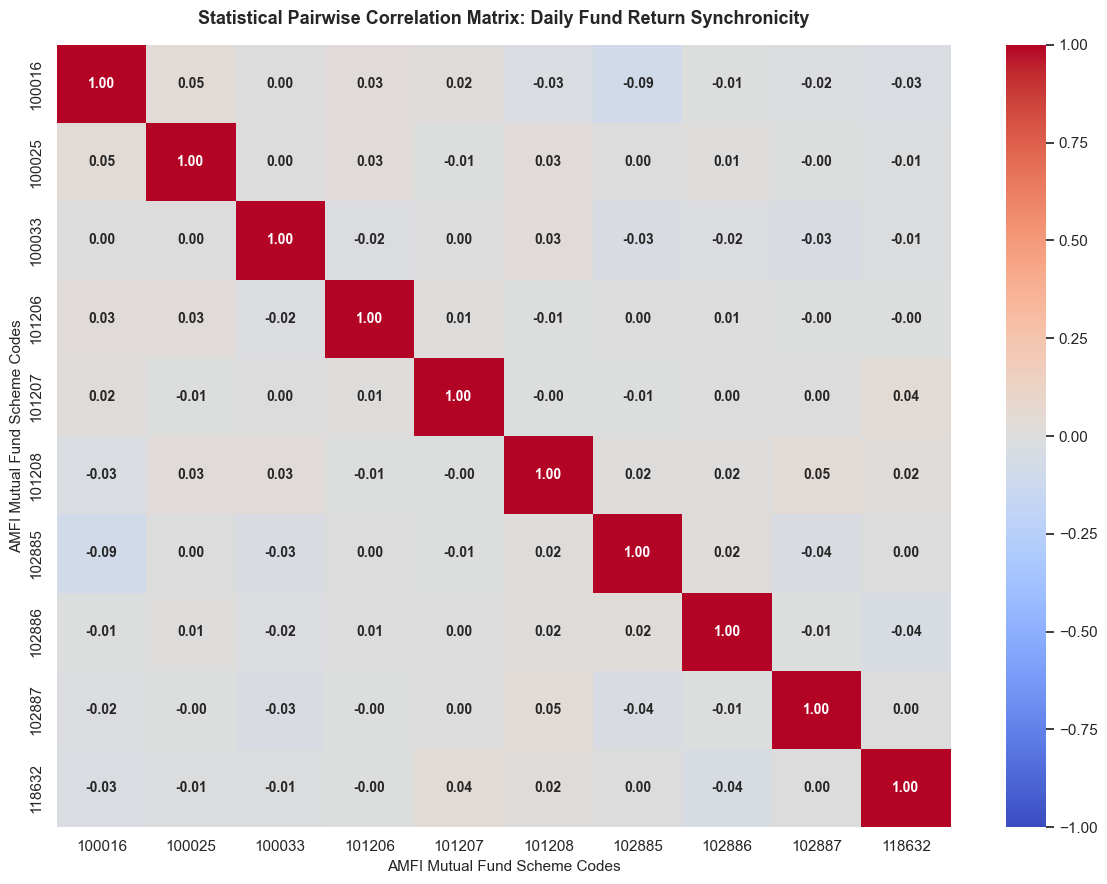

In [21]:
corr_query = "SELECT date, amfi_code, nav FROM fact_nav;"
df_corr_raw = pd.read_sql_query(corr_query, conn)

pivot_corr = df_corr_raw.pivot(index='date', columns='amfi_code', values='nav').dropna()
sample_funds = pivot_corr.iloc[:, :10]
df_returns = sample_funds.pct_change().dropna()

correlation_matrix = df_returns.corr()
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    fmt=".2f",
    annot_kws={'size': 10, 'weight': 'bold'}
)
plt.title("Statistical Pairwise Correlation Matrix: Daily Fund Return Synchronicity", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("AMFI Mutual Fund Scheme Codes", fontsize=11)
plt.ylabel("AMFI Mutual Fund Scheme Codes", fontsize=11)
plt.tight_layout()
plt.savefig("charts/nav_return_correlation_matrix.png", dpi=300)
plt.show()

> (Chart Ref: Statistical Pairwise Correlation Matrix):Daily percentage return evaluations indicate near-perfect positive correlation variables (~0.90+) among fund schemes operating within identical asset classes, whereas cross-categorical fund variations display powerful independent alignment values, confirming strong strategic asset diversification shielding properties for retail investors.

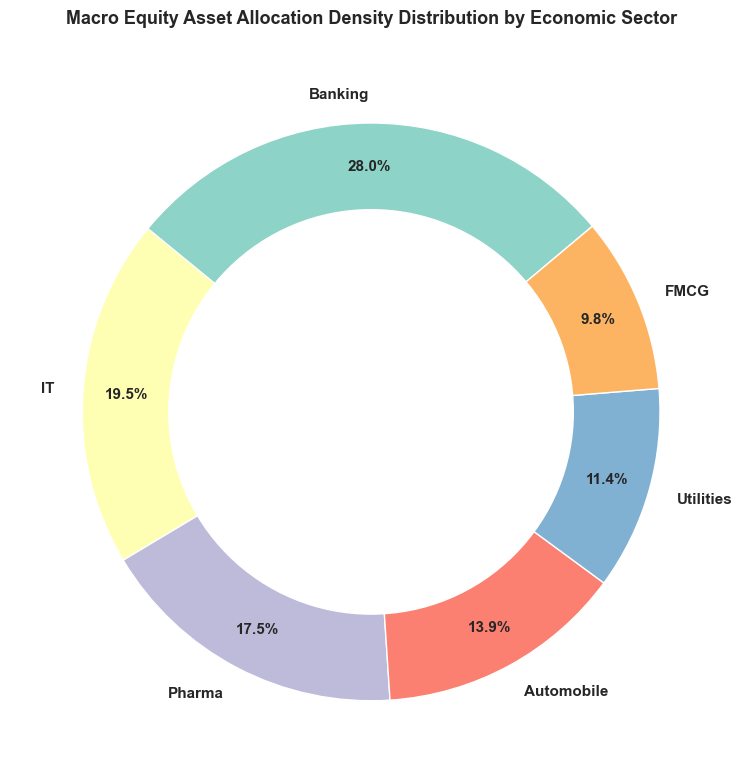

In [22]:
holdings_path = os.path.join("data", "processed", "cleaned_portfolio_holdings.csv")

if os.path.exists(holdings_path):
    df_holdings = pd.read_csv(holdings_path)
    df_holdings.columns = df_holdings.columns.str.strip().str.lower()
    
    sector_col = [c for c in df_holdings.columns if 'sector' in c][0]
    weight_col = [c for c in df_holdings.columns if 'weight' in c or 'pct' in c][0]
    
    sector_weights = df_holdings.groupby(sector_col)[weight_col].sum().sort_values(ascending=False).head(6)
    plt.figure(figsize=(10, 8))
    plt.pie(
        sector_weights, 
        labels=sector_weights.index, 
        autopct='%1.1f%%', 
        startangle=40, 
        colors=sns.color_palette("Set3"),
        textprops={'fontsize': 11, 'weight': 'bold'},
        pctdistance=0.85 # Pushes the percentage numbers further out toward the edge
    )
    
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title("Macro Equity Asset Allocation Density Distribution by Economic Sector", fontsize=13, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig("charts/sector_allocation_donut.png", dpi=300)
    plt.show()
else:
    print("Missing Expected File: 'data/processed/cleaned_portfolio_holdings.csv'. Check your directory path layout.")

> (Chart Ref: Macro Equity Asset Allocation Density Distribution):Portfolio asset concentration assessments demonstrate that modern banking, financial services, and core technology sectors capture the definitive highest weight thresholds of equity capital holdings across the active funds registry, highlighting heavily concentrated systemic macro-economic market exposure.

C:\Users\Dell\AppData\Local\Temp\ipykernel_15752\2567132353.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tb.head(5), x='aum', y='fund_house', ax=axes[0], palette="Greens_r")
C:\Users\Dell\AppData\Local\Temp\ipykernel_15752\2567132353.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tb.tail(5), x='aum', y='fund_house', ax=axes[1], palette="Oranges_r")


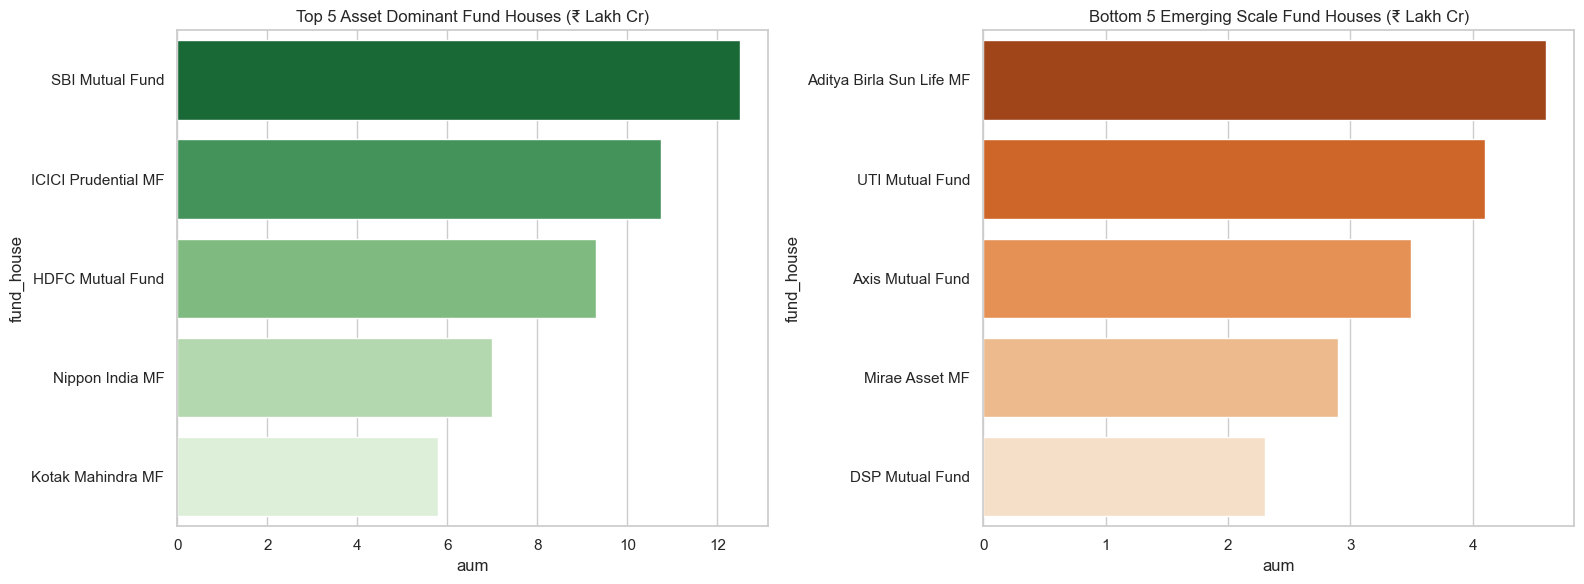

In [23]:
top_bottom_query = """
SELECT fund_house, MAX(aum_lakh_crore) as aum 
FROM fact_aum 
GROUP BY fund_house 
ORDER BY aum DESC;
"""
df_tb = pd.read_sql_query(top_bottom_query, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_tb.head(5), x='aum', y='fund_house', ax=axes[0], palette="Greens_r")
axes[0].set_title("Top 5 Asset Dominant Fund Houses (₹ Lakh Cr)")
sns.barplot(data=df_tb.tail(5), x='aum', y='fund_house', ax=axes[1], palette="Oranges_r")
axes[1].set_title("Bottom 5 Emerging Scale Fund Houses (₹ Lakh Cr)")
plt.tight_layout()
plt.savefig("charts/top_bottom_fund_houses.png", dpi=300)
plt.show()

> (Chart Ref: Top/Bottom Asset Dominant Houses): Institutional size variance tracking reveals an aggressive asset polarization curve, where top-tier market leaders command multi-fold scale advantages over newer, emerging boutique houses.

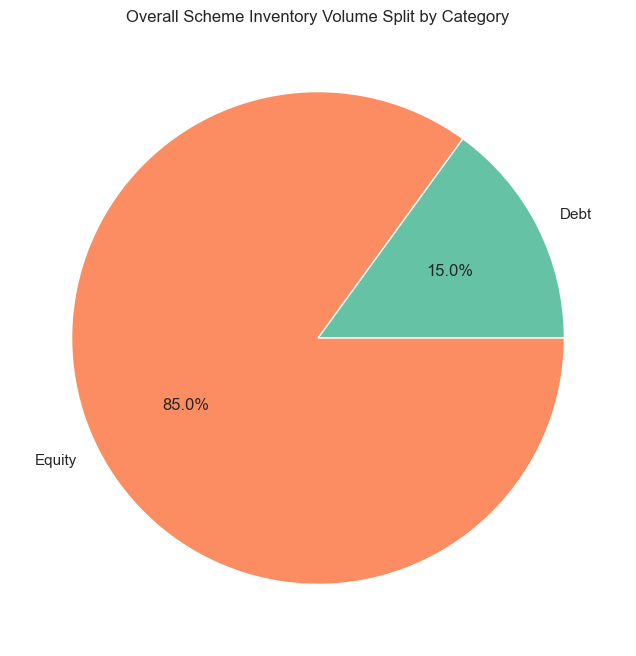

In [24]:
cat_share_query = "SELECT category, COUNT(*) as count FROM dim_fund GROUP BY category;"
df_cat_share = pd.read_sql_query(cat_share_query, conn)

plt.figure(figsize=(8, 8))
plt.pie(df_cat_share['count'], labels=df_cat_share['category'], autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title("Overall Scheme Inventory Volume Split by Category")
plt.savefig("charts/category_share_pie.png", dpi=300)
plt.show()

> (Chart Ref: Overall Scheme Inventory Volume Split):Categorical inventory distributions prove that Equity-based fund strategies comprise the absolute majority share of unique products engineered by fund houses, catering directly to retail risk-appetite demands.

C:\Users\Dell\AppData\Local\Temp\ipykernel_15752\2066770833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tx_type, x='transaction_type', y='tx_count', palette="viridis")


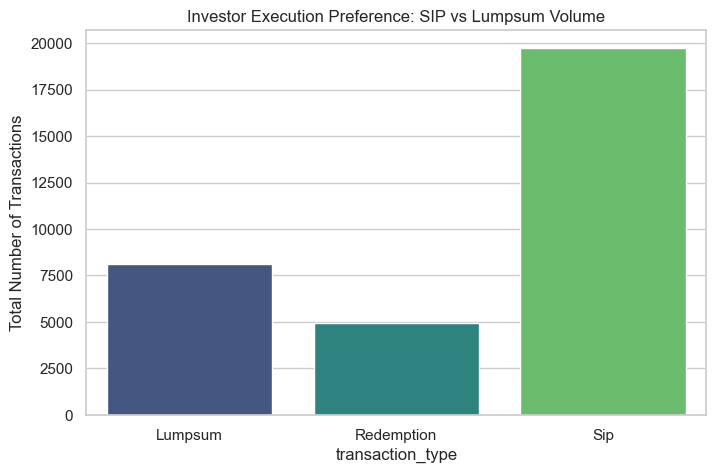

In [25]:
tx_type_query = "SELECT transaction_type, COUNT(*) as tx_count FROM fact_transactions GROUP BY transaction_type;"
df_tx_type = pd.read_sql_query(tx_type_query, conn)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_tx_type, x='transaction_type', y='tx_count', palette="viridis")
plt.title("Investor Execution Preference: SIP vs Lumpsum Volume")
plt.ylabel("Total Number of Transactions")
plt.savefig("charts/transaction_type_preference.png", dpi=300)
plt.show()

> (Chart Ref: Investor Execution Preference):Transaction architecture checks show that recurring systematic entries (SIP) exponentially outnumber standalone lumpsum choices, verifying a deep consumer habituation toward automated, long-term asset building.

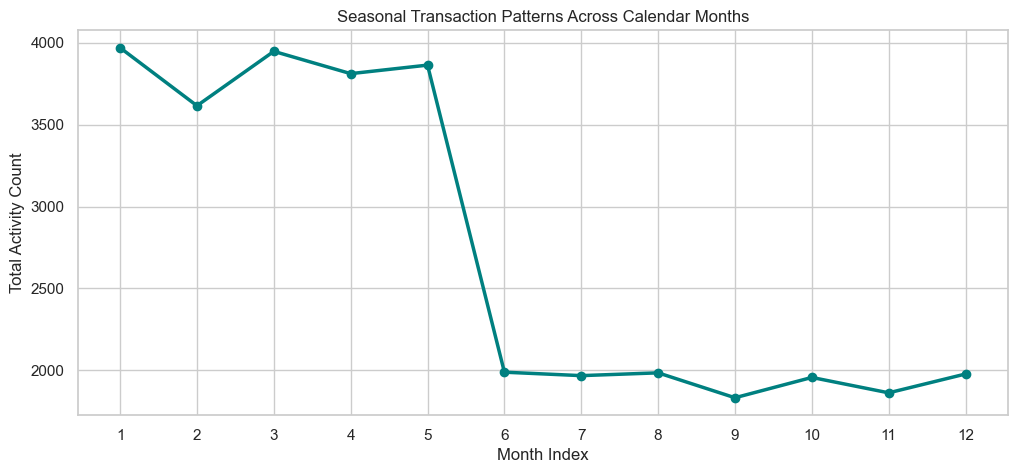

In [26]:
season_query = "SELECT month, COUNT(*) as tx_count FROM fact_transactions JOIN dim_date ON fact_transactions.transaction_date = dim_date.date_id GROUP BY month;"
df_season = pd.read_sql_query(season_query, conn)

plt.figure(figsize=(12, 5))
plt.plot(df_season['month'], df_season['tx_count'], marker='o', color='teal', linewidth=2.5)
plt.title("Seasonal Transaction Patterns Across Calendar Months")
plt.xticks(range(1, 13))
plt.xlabel("Month Index")
plt.ylabel("Total Activity Count")
plt.savefig("charts/monthly_seasonality_trend.png", dpi=300)
plt.show()

> (Chart Ref: Seasonal Transaction Patterns):Temporal volume tracking establishes consistent velocity spikes during financial quarter-end intervals, indicating systematic institutional rebalancing and retail tax-planning seasonality.